In [9]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
file_path = rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching\src\fluorophores\\"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")
import src.formulas as fo
import src.custom_plot as cp
import src.miscellaneous as mi

from numpy import polyfit
from scipy import interpolate as itp

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### cis

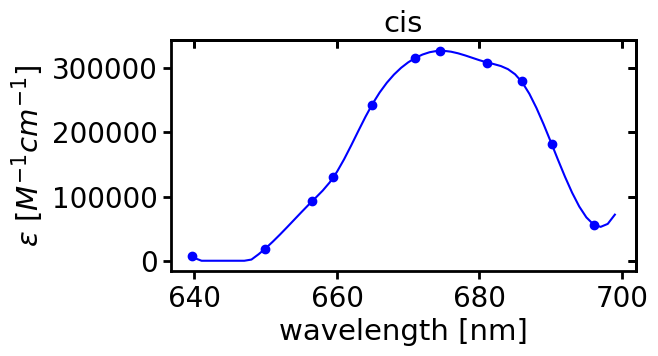

In [7]:
cis = pd.read_csv(file_path + 'cy5_cis_absorption.csv')

important_wavelengths = np.arange(640, 700)
measured_wavelengths = cis['x']
sorted_indices = np.argsort(measured_wavelengths)
measured_wavelengths = measured_wavelengths[sorted_indices]
measured_extinctions = cis[' y']
measured_extinctions = measured_extinctions[sorted_indices]

cis_extinctions = itp.CubicSpline(measured_wavelengths, measured_extinctions)(important_wavelengths)

upper = 800 - max(important_wavelengths)
lower = min(important_wavelengths) - 300
add_lower = np.zeros(shape=lower)
add_upper = np.zeros(shape=upper)

cis_extinctions = np.where(cis_extinctions < 0, 0, cis_extinctions)
cis_extinctions_complete = np.concatenate((add_lower, cis_extinctions, add_upper))

fig, ax = cp.universal_figure(data=[important_wavelengths, cis_extinctions])
fig, ax = cp.universal_figure(type_='scatter', data=[measured_wavelengths, measured_extinctions], axes=ax,
                              ylabel=r'$\epsilon\ [M^{-1}cm^{-1}]$', xlabel='wavelength [nm]', title='cis')

### triplet

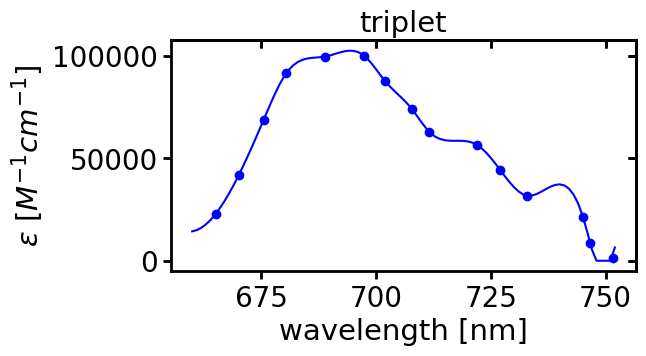

In [14]:
triplet = pd.read_csv(file_path + 'cy5_t1_absorption.csv')

important_wavelengths = np.arange(660, 753)
measured_wavelengths = triplet['x']
sorted_indices = np.argsort(measured_wavelengths)
measured_wavelengths = measured_wavelengths[sorted_indices]
measured_extinctions = triplet[' y']
measured_extinctions = measured_extinctions[sorted_indices]

triplet_extinctions = itp.CubicSpline(measured_wavelengths, measured_extinctions)(important_wavelengths)

upper = 800 - max(important_wavelengths)
lower = min(important_wavelengths) - 300
add_lower = np.zeros(shape=lower)
add_upper = np.zeros(shape=upper)

triplet_extinctions = np.where(triplet_extinctions < 0, 0, triplet_extinctions)
triplet_extinctions_complete = np.concatenate((add_lower, triplet_extinctions, add_upper))

fig, ax = cp.universal_figure(data=[important_wavelengths, triplet_extinctions])
fig, ax = cp.universal_figure(type_='scatter', data=[measured_wavelengths, measured_extinctions], axes=ax,
                              ylabel=r'$\epsilon\ [M^{-1}cm^{-1}]$', xlabel='wavelength [nm]', title='triplet')

### OFF

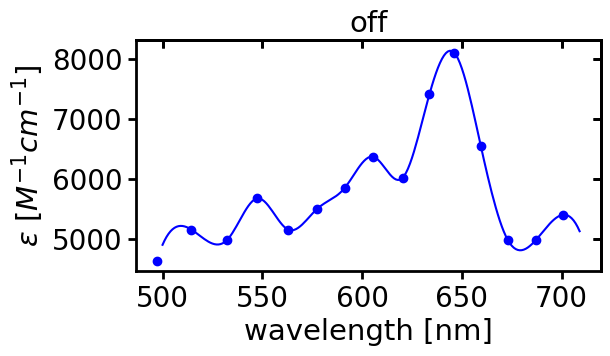

In [11]:
off = pd.read_csv(file_path + 'cy5_off_absorption.csv')

important_wavelengths = np.arange(500, 710)
measured_wavelengths = off['x']
sorted_indices = np.argsort(measured_wavelengths)
measured_wavelengths = measured_wavelengths[sorted_indices]
measured_extinctions = off[' y']
measured_extinctions = measured_extinctions[sorted_indices]

off_extinctions = itp.CubicSpline(measured_wavelengths, measured_extinctions)(important_wavelengths)

upper = 800 - max(important_wavelengths)
lower = min(important_wavelengths) - 300
add_lower = np.zeros(shape=lower)
add_upper = np.zeros(shape=upper)

off_extinctions = np.where(off_extinctions < 0, 0, off_extinctions)
off_extinctions_complete = np.concatenate((add_lower, off_extinctions, add_upper))

fig, ax = cp.universal_figure(data=[important_wavelengths, off_extinctions])
fig, ax = cp.universal_figure(type_='scatter', data=[measured_wavelengths, measured_extinctions], axes=ax,
                              ylabel=r'$\epsilon\ [M^{-1}cm^{-1}]$', xlabel='wavelength [nm]', title='off')

### Cy5

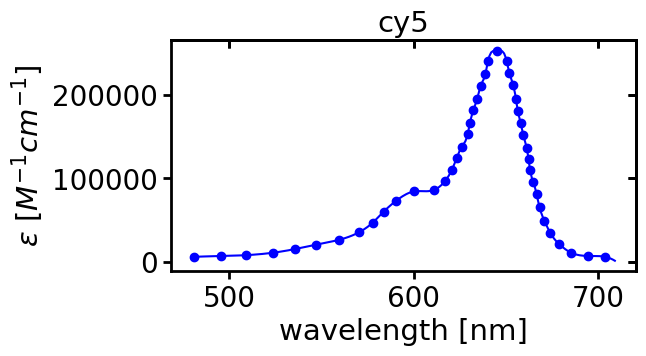

In [15]:
cy5 = pd.read_csv(file_path + 'cy5_absorption.csv')

important_wavelengths = np.arange(480, 710)
measured_wavelengths = cy5['x']
sorted_indices = np.argsort(measured_wavelengths)
measured_wavelengths = measured_wavelengths[sorted_indices]
measured_extinctions = cy5[' y']
measured_extinctions = measured_extinctions[sorted_indices]
cy5_extinctions = itp.CubicSpline(measured_wavelengths, measured_extinctions)(important_wavelengths)



upper = 800 - max(important_wavelengths)
lower = min(important_wavelengths) - 300
add_lower = np.zeros(shape=lower)
add_upper = np.zeros(shape=upper)

cy5_extinctions = np.where(cy5_extinctions < 0, 0, cy5_extinctions)
cy5_extinctions_complete = np.concatenate((add_lower, cy5_extinctions, add_upper))

fig, ax = cp.universal_figure(data=[important_wavelengths, cy5_extinctions])
fig, ax = cp.universal_figure(type_='scatter', data=[measured_wavelengths, measured_extinctions], axes=ax,
                              ylabel=r'$\epsilon\ [M^{-1}cm^{-1}]$', xlabel='wavelength [nm]', title='cy5')

## Emission

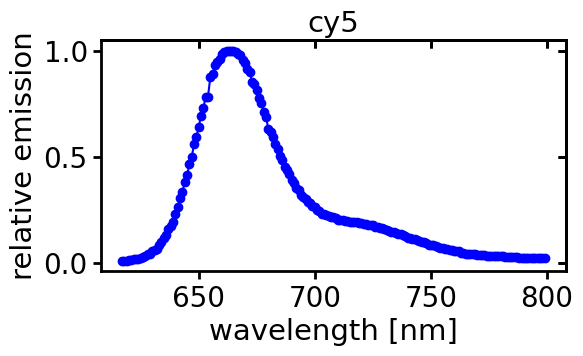

In [17]:
emission = pd.read_csv(file_path + 'cy5_emission.csv')

important_wavelengths = np.arange(620, 800)
measured_wavelengths = emission['Wavelength']
sorted_indices = np.argsort(measured_wavelengths)
measured_wavelengths = measured_wavelengths[sorted_indices]
measured_emissions = emission['Cy5 EM']
measured_emissions = measured_emissions[sorted_indices]

cy5_emissions = itp.CubicSpline(measured_wavelengths, measured_emissions)(important_wavelengths)

upper = 800 - max(important_wavelengths)
lower = min(important_wavelengths) - 300
add_lower = np.zeros(shape=lower)
add_upper = np.zeros(shape=upper)

cy5_emissions = np.where(cy5_emissions < 0, 0, cy5_emissions)
cy5_emissions_complete = np.concatenate((add_lower, cy5_emissions, add_upper))

fig, ax = cp.universal_figure(data=[important_wavelengths, cy5_emissions])
fig, ax = cp.universal_figure(type_='scatter', data=[measured_wavelengths, measured_emissions], axes=ax,
                              ylabel='relative emission', xlabel='wavelength [nm]', title='cy5')

## Spectral overlap integrals

In [18]:
j_off = fo.calculate_spectral_overlap_integral(cy5_emissions_complete, off_extinctions_complete, wavelengths=np.arange(300., 801., 1))

In [19]:
j_cy5 = fo.calculate_spectral_overlap_integral(cy5_emissions_complete, cy5_extinctions_complete, wavelengths=np.arange(300., 801., 1))

In [20]:
j_cis = fo.calculate_spectral_overlap_integral(cy5_emissions_complete, cis_extinctions_complete, wavelengths=np.arange(300., 801., 1))

In [21]:
j_triplet = fo.calculate_spectral_overlap_integral(cy5_emissions_complete, triplet_extinctions_complete, wavelengths=np.arange(300., 801., 1))

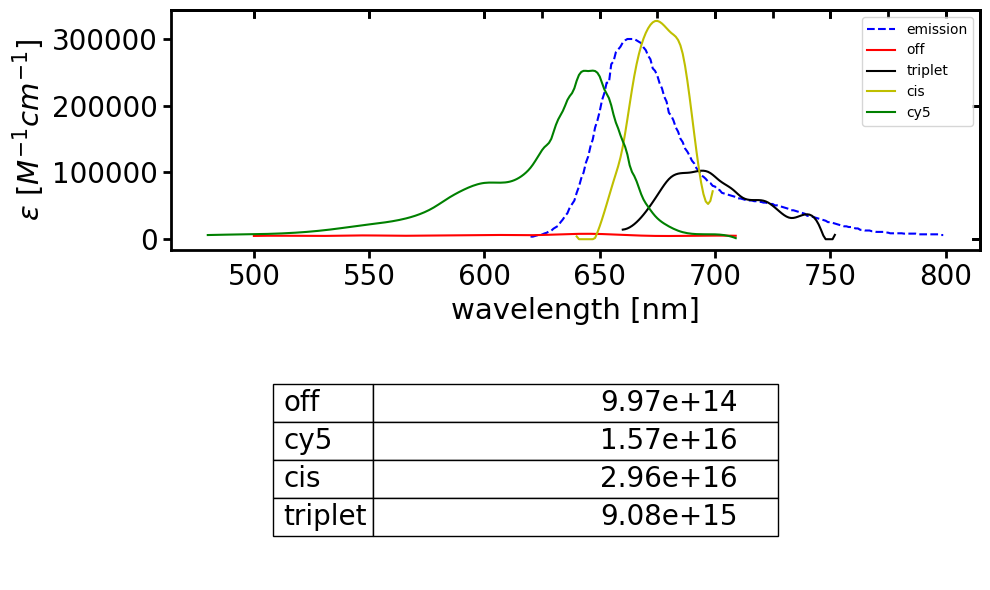

In [23]:
fig, ax = cp.universal_figure(data=[np.arange(620, 800), cy5_emissions*300000], label='emission', ls='--', color='b',
                              ncols=1, nrows=2, fig_width=10, fig_height=6)
_, _ = cp.universal_figure(data=[np.arange(500, 710), off_extinctions], label='off', fig=fig, axes=ax[0], color='r')
_, _ = cp.universal_figure(data=[np.arange(660, 753), triplet_extinctions], label='triplet', fig=fig, axes=ax[0], color='k')
_, _ = cp.universal_figure(data=[np.arange(640, 700), cis_extinctions], label='cis', fig=fig, axes=ax[0], color='y')
_, _ = cp.universal_figure(data=[np.arange(480, 710), cy5_extinctions], label='cy5', fig=fig, axes=ax[0], 
                           legend=True, color='g', xlabel='wavelength [nm]', ylabel=r'$\epsilon\ [M^{-1} cm^{-1}]$')
fig = mi.delete_subplots(fig, ax, 1)
new_ax = fig.add_subplot(212)
new_ax.axis('off')
table = new_ax.table(cellText=[[f'{j_off:.2e}'], [f'{j_cy5:.2e}'], [f'{j_cis:.2e}'], [f'{j_triplet:.2e}']], 
                     rowLabels=['off', 'cy5', 'cis', 'triplet'], loc='center')
table.scale(0.5, 2)
table.set_fontsize(20)
fig.tight_layout()

## FRET rate and efficiency versus distance

### homoFRET

In [12]:
distances = np.arange(1, 20, 1)
rates = []
for distance in distances:
    rate = fo.calculate_fret_rate(distance, 1e8, j_cy5, 0.66, 1)
    rates.append(rate)

def efficiency(fret_rate, fluorescence_lifetime):
    tau_strich = 1/(1/fluorescence_lifetime + fret_rate)
    E = 1 - (tau_strich/fluorescence_lifetime)
    return E

es = []
for rate in rates:
    e = efficiency(rate, 1e-9)
    es.append(e)

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:xlabel='distance [nm]', ylabel='rate [1/s]'>]],
       dtype=object))

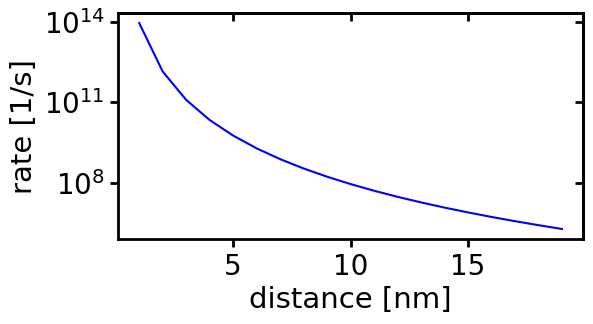

In [13]:
cp.universal_figure(type_='line', data=[distances, rates], ylabel='rate [1/s]', xlabel='distance [nm]', yscale='log')

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:xlabel='distance [nm]', ylabel='Efficiency'>]],
       dtype=object))

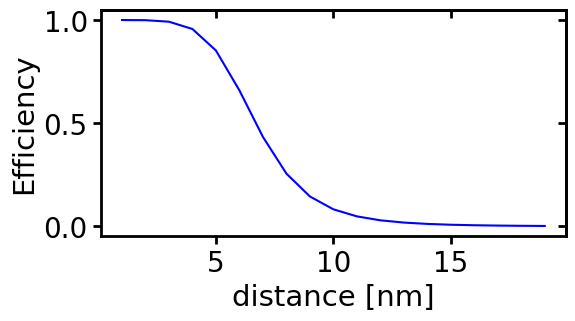

In [14]:
cp.universal_figure(data=[distances, es], ylabel='Efficiency', xlabel='distance [nm]')

### OFF FRET

In [15]:
distances = np.arange(1, 20, 1)
rates = []
for distance in distances:
    rate = fo.calculate_fret_rate(distance, 1e8, j_off, 0.66, 1)
    rates.append(rate)

def efficiency(fret_rate, fluorescence_lifetime):
    tau_strich = 1/(1/fluorescence_lifetime + fret_rate)
    E = 1 - (tau_strich/fluorescence_lifetime)
    return E

es = []
for rate in rates:
    e = efficiency(rate, 1e-9)
    es.append(e)

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:xlabel='distance [nm]', ylabel='rate [1/s]'>]],
       dtype=object))

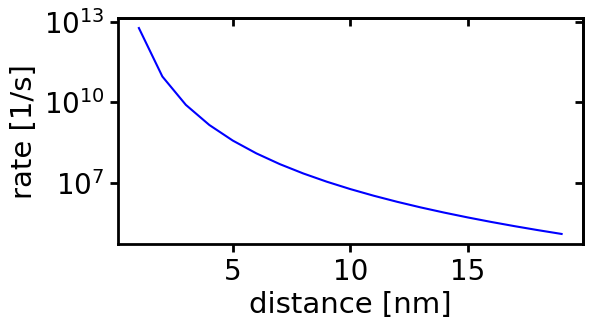

In [16]:
cp.universal_figure(type_='line', data=[distances, rates], ylabel='rate [1/s]', xlabel='distance [nm]', yscale='log')

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:xlabel='distance [nm]', ylabel='Efficiency'>]],
       dtype=object))

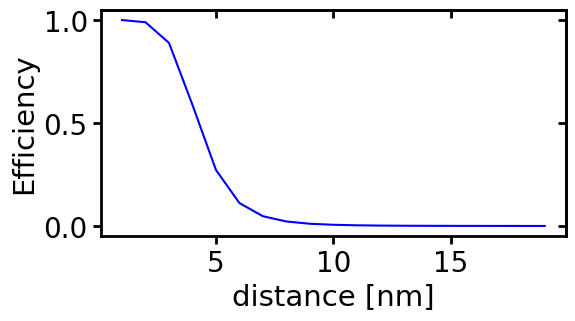

In [17]:
cp.universal_figure(data=[distances, es], ylabel='Efficiency', xlabel='distance [nm]')